# Pipeline Preprocessing Citra Daun Anggur
**Task 1 — Feature Extraction**

| # | Tahap | Teknik |
|---|-------|--------|
| 1 | Segmentasi Latar Belakang | HSV Masking |
| 2 | Pemerataan Pencahayaan | CLAHE |
| 3 | Penstabilan Rasio Geometri | Zero-Padding & Resize |
| 4 | Normalisasi Skala | Min-Max (÷ 255) |
| 5 | Augmentasi Geometris | Rotasi + Flip |

## 0. Import Library & Konfigurasi Path

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from sklearn.metrics import classification_report
from skimage.feature import graycomatrix, graycoprops

# ── Konfigurasi ──────────────────────────────────────────────
DATASET_DIR   = Path("Dataset")
OUTPUT_DIR    = Path("Preprocessed")
TARGET_SIZE1   = 32
TARGET_SIZE2   = 64
TARGET_SIZE3   = 128
RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

# Daftar kelas (sub-folder)
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if (DATASET_DIR / d).is_dir()
])
print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", len(CLASS_NAMES))

Kelas ditemukan: ['Grape Esca (Black_Measles)', 'Grape Leaf blight (Isariopsis_Leaf_Spot)', 'grape leaf Healthy', 'grape leaf black rot']
Jumlah kelas   : 4


## 1. Segmentasi Latar Belakang (HSV Masking)
Mengisolasi objek daun dan menghitamkan area latar belakang menggunakan ruang warna HSV.  
**Tujuan:** Mencegah model salah mengenali warna tanah, pot, atau bayangan sebagai bercak penyakit.

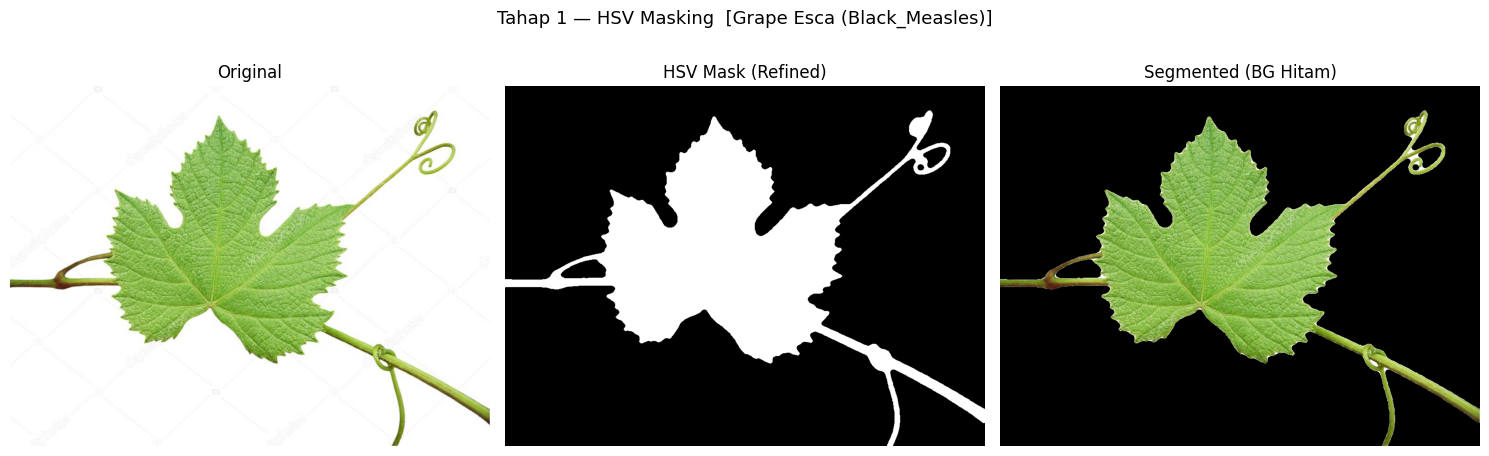

In [3]:
def segment_leaf_hsv(image_bgr, min_area_ratio=0.01):
    """
    Segmentasi daun dengan HSV + pembersihan komponen.
    - Menggabungkan rentang warna daun (hijau/kuning/coklat/merah)
    - Menolak piksel low-saturation (background kusam)
    - Menyisakan komponen terbesar agar background tidak ikut
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Rentang warna daun (lebih ketat)
    lower_green = np.array([20, 35, 25])
    upper_green = np.array([95, 255, 255])

    lower_yellow = np.array([15, 40, 35])
    upper_yellow = np.array([35, 255, 255])

    lower_brown = np.array([5, 50, 20])
    upper_brown = np.array([20, 255, 220])

    lower_red1 = np.array([0, 50, 30])
    upper_red1 = np.array([12, 255, 255])
    lower_red2 = np.array([160, 50, 30])
    upper_red2 = np.array([180, 255, 255])

    # Mask warna
    mask_color  = cv2.inRange(hsv, lower_green, upper_green)
    mask_color |= cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask_color |= cv2.inRange(hsv, lower_brown, upper_brown)
    mask_color |= cv2.inRange(hsv, lower_red1, upper_red1)
    mask_color |= cv2.inRange(hsv, lower_red2, upper_red2)

    # Tolak background abu/gelap (S dan V terlalu rendah)
    mask_sv = cv2.inRange(hsv, np.array([0, 35, 25]), np.array([180, 255, 255]))
    mask = cv2.bitwise_and(mask_color, mask_sv)

    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Keep komponen terbesar (leaf utama)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]  # abaikan background index 0
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

        h, w = mask.shape[:2]
        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    # Haluskan tepi akhir
    refined = cv2.medianBlur(refined, 5)
    result = cv2.bitwise_and(image_bgr, image_bgr, mask=refined)
    return result, refined


# ── Demo visual ──────────────────────────────────────────────
sample_class = CLASS_NAMES[0]
sample_path  = DATASET_DIR / sample_class
sample_files = sorted([
    f for f in os.listdir(sample_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])
# img = cv2.imread(str(sample_path / sample_files[0]))
img = cv2.imread("Dataset\grape leaf Healthy\grape leaf Healthy (3).jpg")

seg, msk = segment_leaf_hsv(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(msk, cmap="gray")
axes[1].set_title("HSV Mask (Refined)")
axes[2].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
axes[2].set_title("Segmented (BG Hitam)")
for ax in axes: ax.axis("off")
plt.suptitle(f"Tahap 1 — HSV Masking  [{sample_class}]", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Pemerataan Pencahayaan (CLAHE)
Meratakan kontras pencahayaan secara lokal (per blok piksel) pada kanal L di ruang warna LAB.  
**Tujuan:** Menghilangkan efek silau matahari & bayangan tajam agar detail penyakit tetap terekstrak.

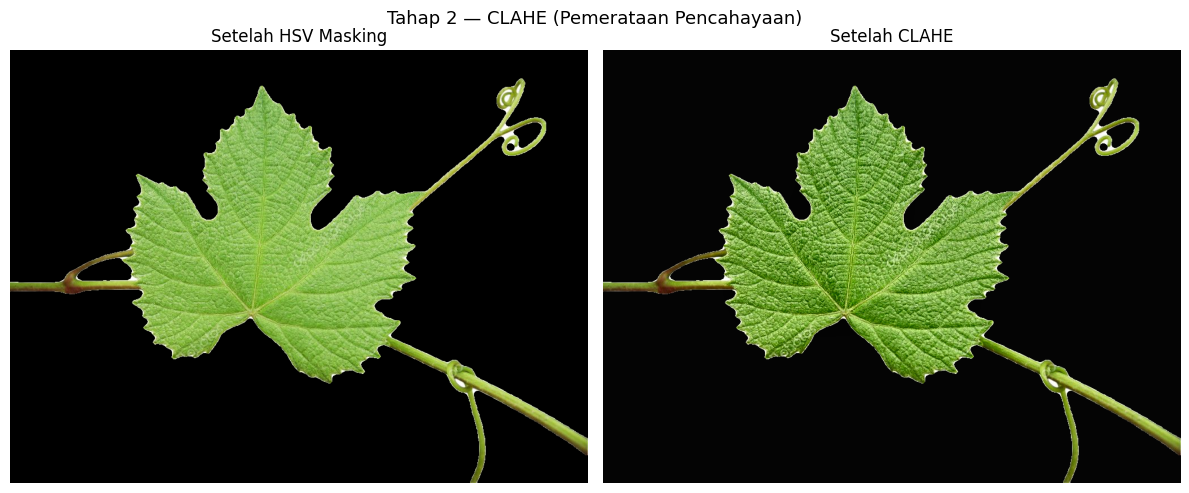

In [4]:
def apply_clahe(image_bgr, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Menerapkan CLAHE pada kanal L (Lightness) di ruang warna LAB.
    Kontras diperbaiki secara lokal tanpa mengubah pigmen warna asli.
    """
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l_channel)

    lab_eq = cv2.merge([l_eq, a_channel, b_channel])
    result = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    return result


# ── Demo visual ──────────────────────────────────────────────
clahe_result = apply_clahe(seg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
axes[0].set_title("Setelah HSV Masking")
axes[1].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[1].set_title("Setelah CLAHE")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 2 — CLAHE (Pemerataan Pencahayaan)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Penstabilan Rasio Geometri (Zero-Padding & Resize)
Menambahkan bingkai hitam (padding) hingga gambar menjadi persegi sempurna, lalu diperkecil ke resolusi target.  
**Tujuan:** Memenuhi syarat input model tanpa mendistorsi anatomi daun / bentuk penyakit.

In [5]:
def zero_pad_and_resize(image_bgr, target_size=224):
    """
    1. Zero-padding → jadikan persegi (sisi = max(h, w))
    2. Resize       → target_size × target_size
    Aspect ratio asli dipertahankan; area tambahan diisi hitam.
    """
    h, w = image_bgr.shape[:2]
    max_side = max(h, w)

    # Buat canvas hitam persegi
    canvas = np.zeros((max_side, max_side, 3), dtype=np.uint8)

    # Letakkan gambar di tengah canvas
    y_offset = (max_side - h) // 2
    x_offset = (max_side - w) // 2
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = image_bgr

    # Resize ke target
    resized = cv2.resize(canvas, (target_size, target_size),
                         interpolation=cv2.INTER_AREA)
    return resized

## Resize 32 x 32

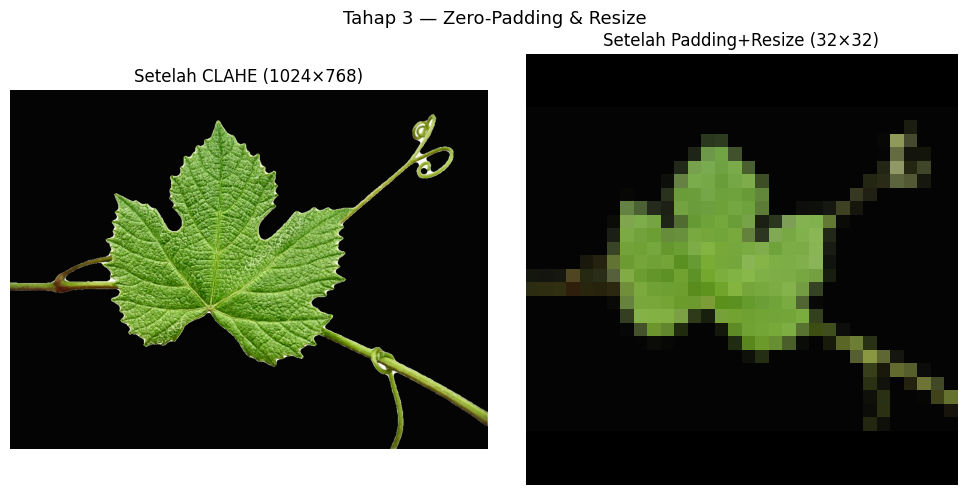

In [6]:

# ── Demo visual ──────────────────────────────────────────────
padded = zero_pad_and_resize(clahe_result, TARGET_SIZE1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Setelah CLAHE ({clahe_result.shape[1]}×{clahe_result.shape[0]})")
axes[1].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Padding+Resize ({TARGET_SIZE1}×{TARGET_SIZE1})")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 3 — Zero-Padding & Resize", fontsize=13)
plt.tight_layout()
plt.show()

## Resize 64 x 64

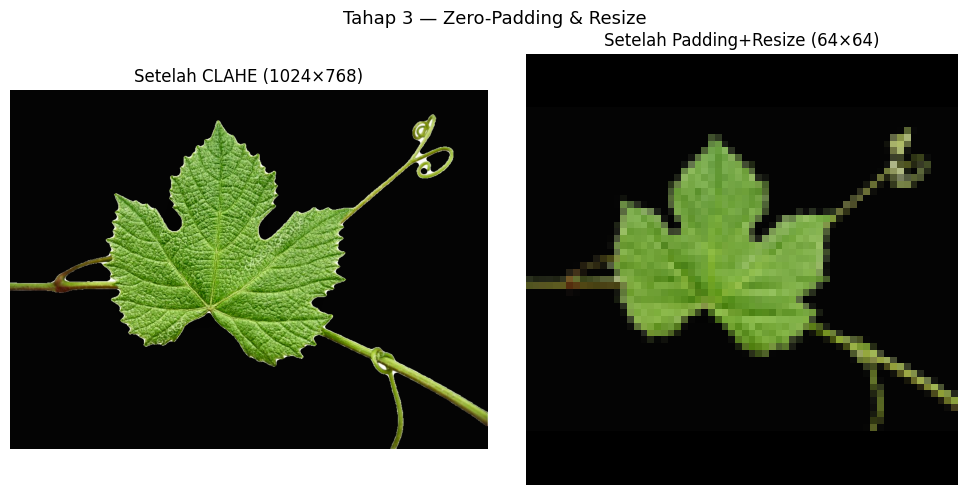

In [7]:

# ── Demo visual ──────────────────────────────────────────────
padded = zero_pad_and_resize(clahe_result, TARGET_SIZE2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Setelah CLAHE ({clahe_result.shape[1]}×{clahe_result.shape[0]})")
axes[1].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Padding+Resize ({TARGET_SIZE2}×{TARGET_SIZE2})")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 3 — Zero-Padding & Resize", fontsize=13)
plt.tight_layout()
plt.show()

## Resize 128 x 128

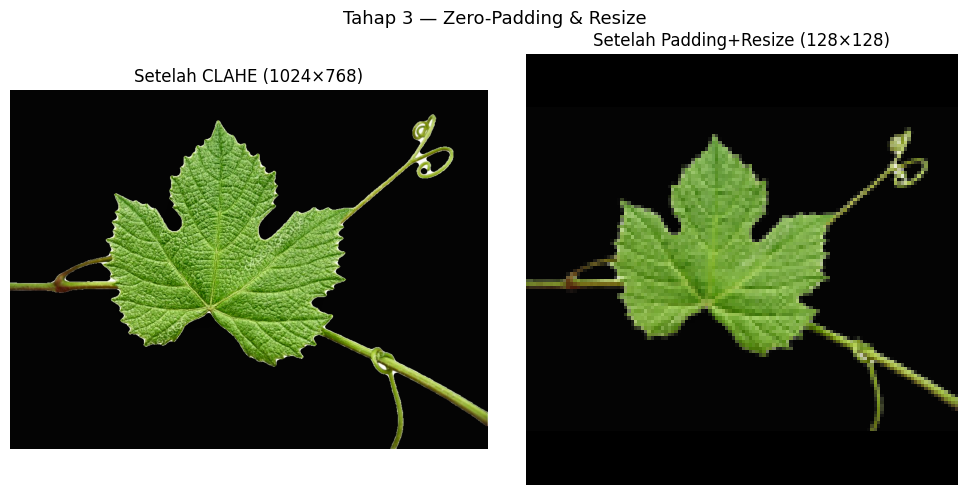

In [8]:

# ── Demo visual ──────────────────────────────────────────────
padded = zero_pad_and_resize(clahe_result, TARGET_SIZE3)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Setelah CLAHE ({clahe_result.shape[1]}×{clahe_result.shape[0]})")
axes[1].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Padding+Resize ({TARGET_SIZE3}×{TARGET_SIZE3})")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 3 — Zero-Padding & Resize", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Normalisasi Skala (Min-Max Normalization)
Membagi seluruh nilai matriks piksel dengan 255 sehingga rentang baru menjadi **[0, 1]**.  
**Tujuan:** Meringankan beban komputasi, menstabilkan kalkulasi matematis, dan mencegah OOM.

Tipe data  : float32
Nilai min  : 0.0000
Nilai max  : 0.9255
Shape      : (128, 128, 3)


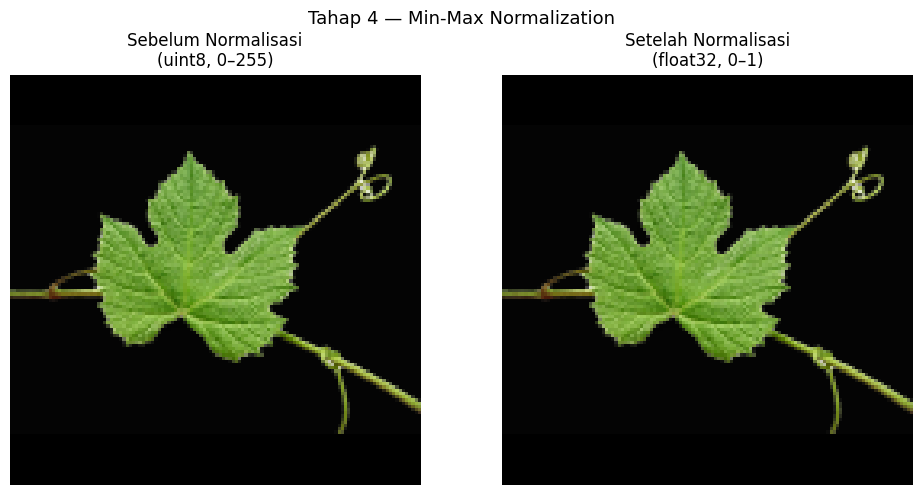

In [9]:
def normalize_minmax(image_bgr):
    """
    Min-Max Normalization: pixel / 255.0
    Output bertipe float32 dengan rentang [0, 1].
    """
    return image_bgr.astype(np.float32) / 255.0


# ── Demo visual ──────────────────────────────────────────────
normed = normalize_minmax(padded)

print(f"Tipe data  : {normed.dtype}")
print(f"Nilai min  : {normed.min():.4f}")
print(f"Nilai max  : {normed.max():.4f}")
print(f"Shape      : {normed.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Sebelum Normalisasi\n(uint8, 0–255)")
axes[1].imshow(cv2.cvtColor(normed, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Normalisasi\n(float32, 0–1)")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 4 — Min-Max Normalization", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Augmentasi Geometris (Data Augmentation)
Memutar dan membalikkan (flip horizontal/vertikal) gambar secara acak.  
**Tujuan:** Mensimulasikan kondisi foto dunia nyata agar model benar-benar belajar karakteristik penyakit, bukan menghafal koordinat piksel.

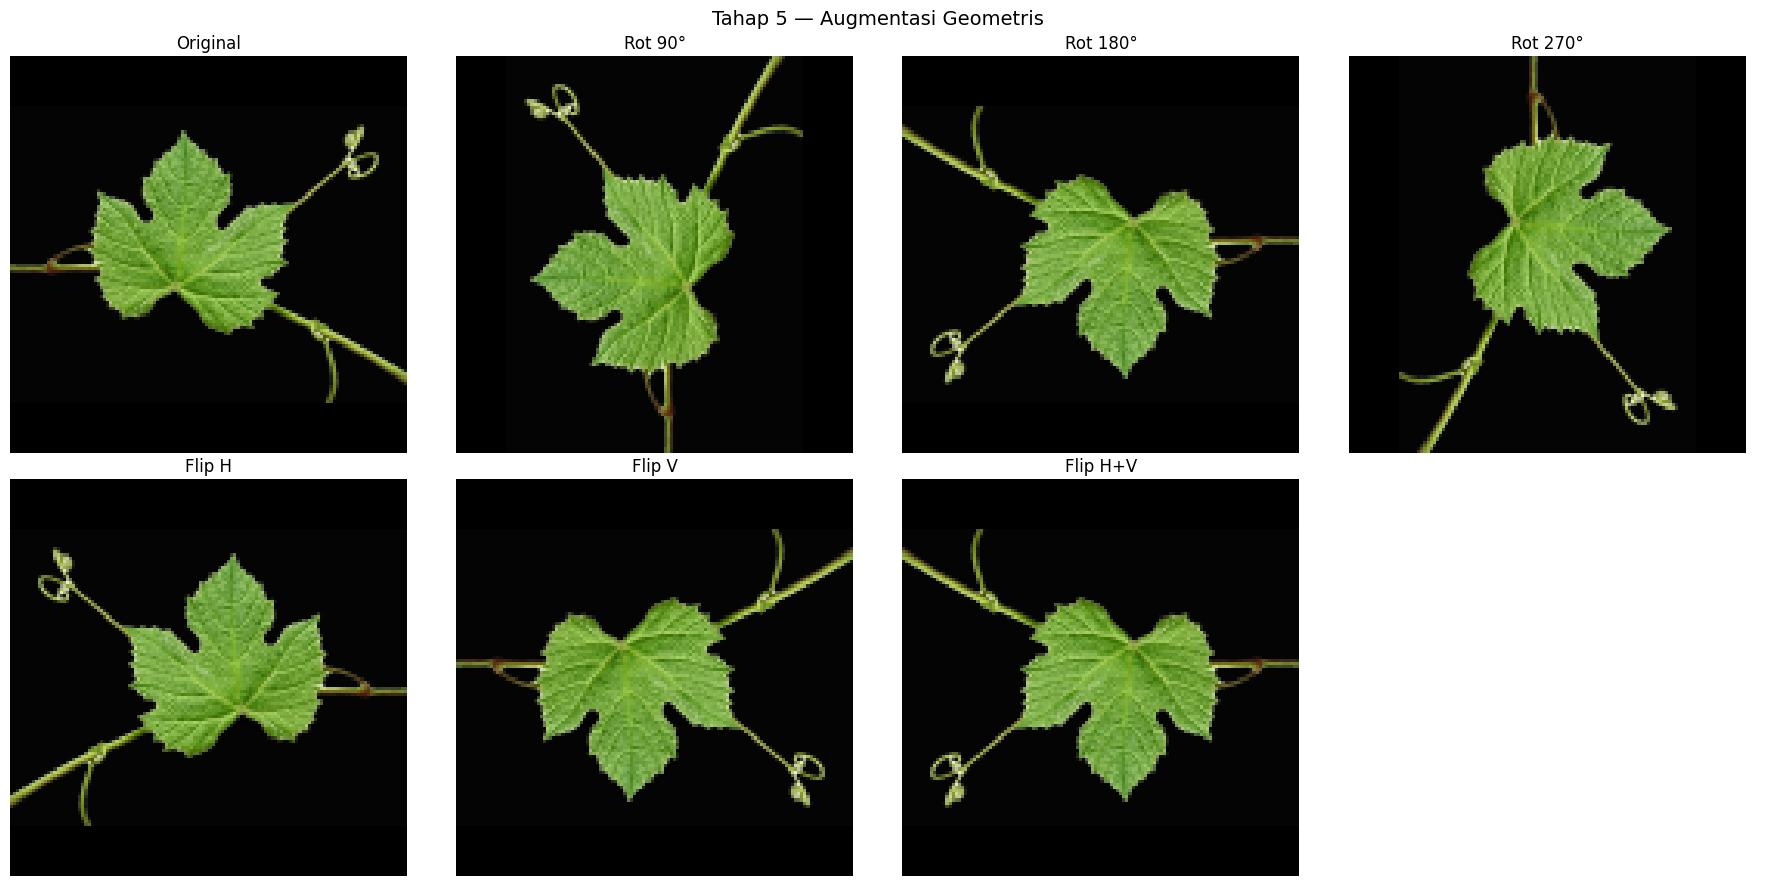

In [10]:
def augment_image(image):
    """
    Augmentasi geometris acak:
      - Rotasi 90°/180°/270°
      - Flip horizontal
      - Flip vertikal
      - Flip horizontal + vertikal
    Mengembalikan list gambar hasil augmentasi (TIDAK termasuk gambar asli).
    """
    augmented = []

    # Rotasi 90°, 180°, 270°
    for k in [1, 2, 3]:
        augmented.append(np.rot90(image, k=k).copy())

    # Flip horizontal
    augmented.append(np.flip(image, axis=1).copy())

    # Flip vertikal
    augmented.append(np.flip(image, axis=0).copy())

    # Flip horizontal + vertikal (setara rotasi 180° + flip)
    augmented.append(np.flip(image, axis=(0, 1)).copy())

    return augmented


# ── Demo visual ──────────────────────────────────────────────
aug_imgs = augment_image(normed)
labels   = ["Rot 90°", "Rot 180°", "Rot 270°",
            "Flip H", "Flip V", "Flip H+V"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
# Gambar asli di posisi pertama
axes[0, 0].imshow(cv2.cvtColor(normed, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for idx, (aug, lbl) in enumerate(zip(aug_imgs, labels)):
    row, col = divmod(idx + 1, 4)
    axes[row, col].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(lbl)
    axes[row, col].axis("off")

# Matikan axis kosong
axes[1, 3].axis("off")

plt.suptitle("Tahap 5 — Augmentasi Geometris", fontsize=14)
plt.tight_layout()
plt.show()

## Ringkasan Visual — 1 Gambar Melewati Semua Tahap Preprocessing
Menampilkan hasil **setiap step** secara berurutan pada satu gambar sampel.

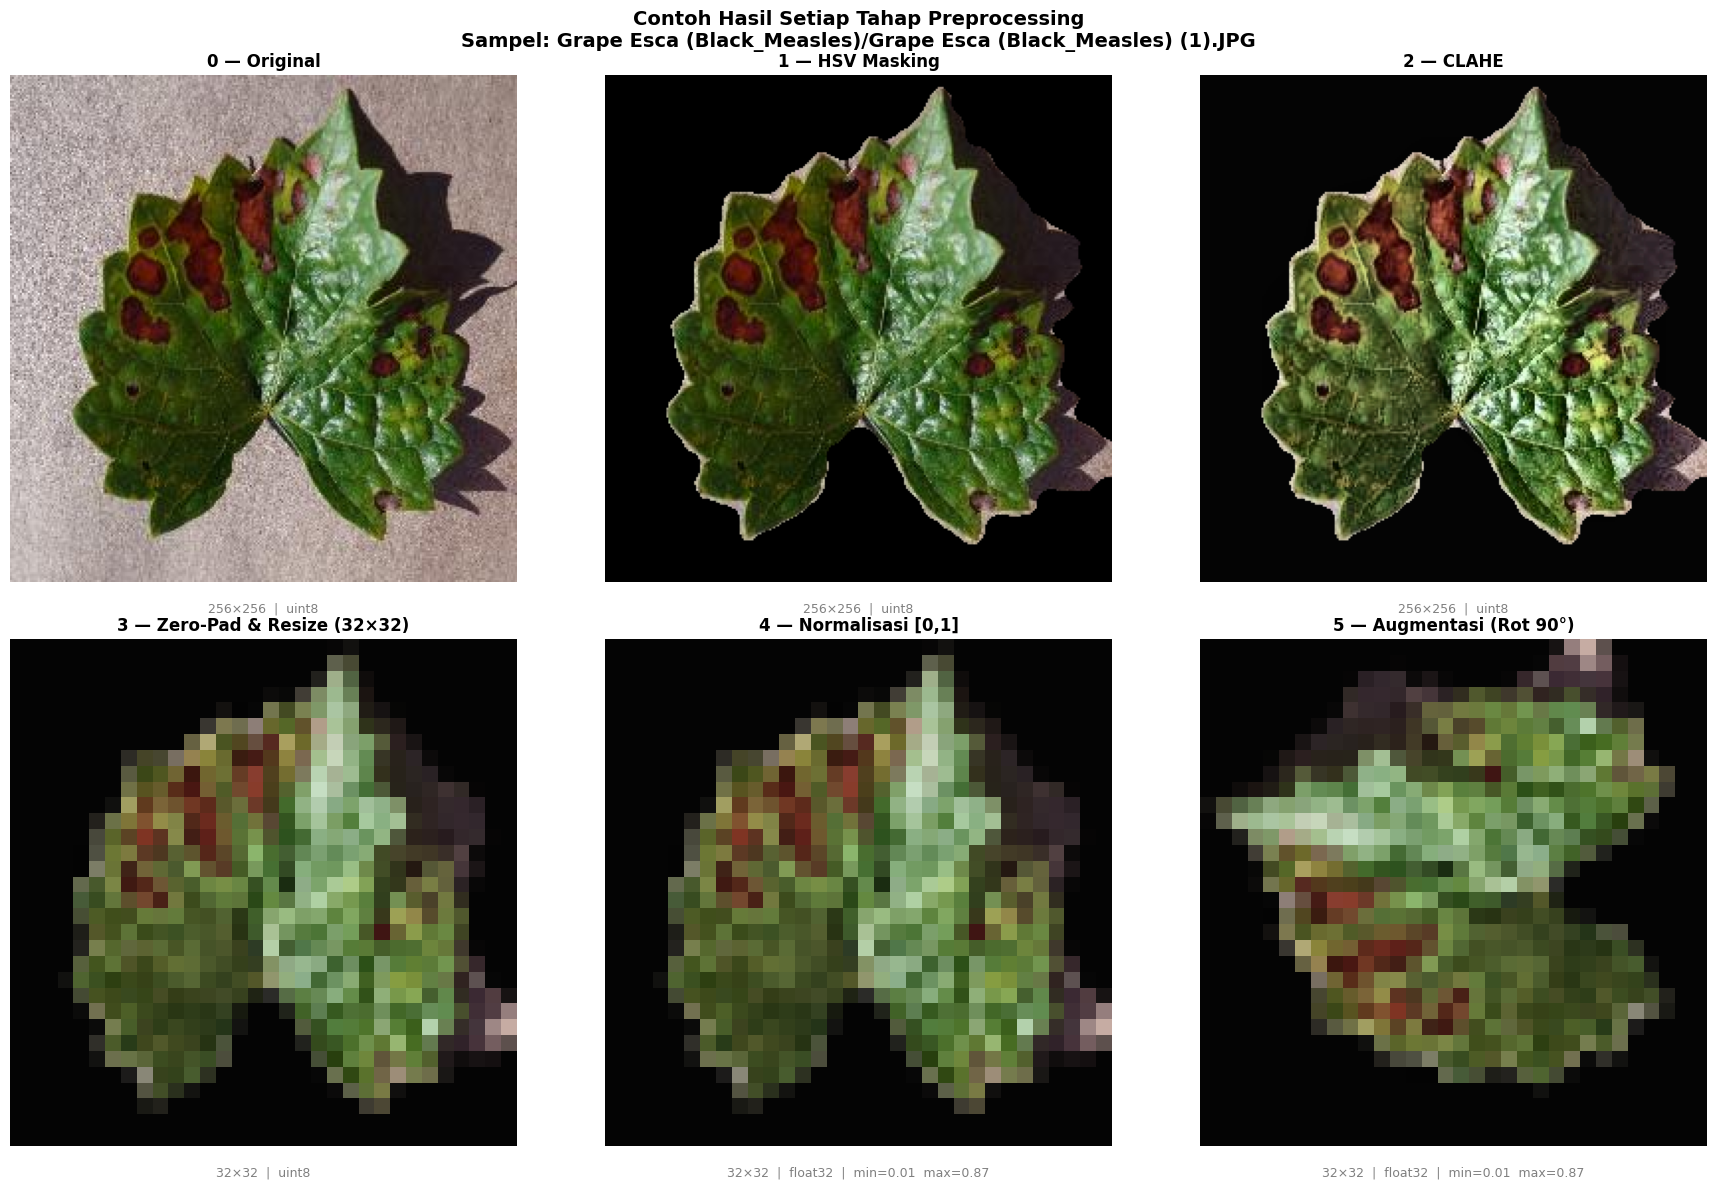

In [11]:
# ── Ambil 1 gambar sampel ─────────────────────────────────────
sample_class = CLASS_NAMES[0]
sample_dir   = DATASET_DIR / sample_class
sample_file  = sorted([f for f in os.listdir(sample_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])[0]
original = cv2.imread(str(sample_dir / sample_file))

# ── Jalankan tiap tahap satu per satu ────────────────────────
step1_hsv, mask       = segment_leaf_hsv(original)
step2_clahe           = apply_clahe(step1_hsv)
step3_padresize       = zero_pad_and_resize(step2_clahe, TARGET_SIZE1)
step4_norm            = normalize_minmax(step3_padresize)
step5_aug_list        = augment_image(step4_norm)
step5_sample          = step5_aug_list[0]   # ambil rotasi 90° sebagai contoh

# ── Siapkan data untuk plot ───────────────────────────────────
stages = [
    ("0 — Original",                   original,       True),
    ("1 — HSV Masking",                step1_hsv,      True),
    ("2 — CLAHE",                      step2_clahe,    True),
    ("3 — Zero-Pad & Resize (32×32)",step3_padresize,True),
    ("4 — Normalisasi [0,1]",          step4_norm,     False),
    ("5 — Augmentasi (Rot 90°)",       step5_sample,   False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (title, img, is_uint8) in enumerate(stages):
    row, col = divmod(idx, 3)
    ax = axes[row][col]

    if is_uint8:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        # float32 [0,1] — clip untuk keamanan tampilan
        display = np.clip(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0, 1)
        ax.imshow(display)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

    # Tambahkan info shape & dtype di bawah judul
    h, w = img.shape[:2]
    dtype = img.dtype
    info = f"{w}×{h}  |  {dtype}"
    if not is_uint8:
        info += f"  |  min={img.min():.2f}  max={img.max():.2f}"
    ax.text(0.5, -0.04, info, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='gray')

plt.suptitle(f"Contoh Hasil Setiap Tahap Preprocessing\nSampel: {sample_class}/{sample_file}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Ekstraksi Fitur Warna dengan Histogram HSV

In [12]:
def extract_hsv_hist_features(
    image_bgr,
    grid_size=(2, 2),   # 4-kuadran
    bins_h=8,
    bins_s=8,
    bins_v=8
):
    """
    Ekstraksi fitur warna HSV histogram per kuadran.
    Output: vektor fitur 1D.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    gh, gw = grid_size

    features = []

    for i in range(gh):
        for j in range(gw):
            y0 = int(i * h / gh)
            y1 = int((i + 1) * h / gh)
            x0 = int(j * w / gw)
            x1 = int((j + 1) * w / gw)

            cell = hsv[y0:y1, x0:x1]

            hist_h = cv2.calcHist([cell], [0], None, [bins_h], [0, 180])
            hist_s = cv2.calcHist([cell], [1], None, [bins_s], [0, 256])
            hist_v = cv2.calcHist([cell], [2], None, [bins_v], [0, 256])

            hist_h = cv2.normalize(hist_h, None).flatten()
            hist_s = cv2.normalize(hist_s, None).flatten()
            hist_v = cv2.normalize(hist_v, None).flatten()

            features.extend(hist_h)
            features.extend(hist_s)
            features.extend(hist_v)

    return np.array(features, dtype=np.float32)

# Ekstraksi Fitur Tekstur dengan GLCM

In [13]:
def extract_glcm_features(
    image_bgr,
    distances=(1, 2, 3),
    angles=(0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
    levels=32
):
    """
    Ekstraksi fitur tekstur menggunakan GLCM pada grayscale.
    Output: vektor fitur 1D.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Kuantisasi grayscale ke levels tertentu
    gray_q = np.floor(gray.astype(np.float32) * levels / 256.0).astype(np.uint8)
    gray_q = np.clip(gray_q, 0, levels - 1)

    glcm = graycomatrix(
        gray_q,
        distances=list(distances),
        angles=list(angles),
        levels=levels,
        symmetric=True,
        normed=True
    )

    props = ["contrast", "homogeneity", "energy", "correlation"]
    features = []

    for prop in props:
        values = graycoprops(glcm, prop)
        features.extend(values.flatten())

    return np.array(features, dtype=np.float32)

In [14]:
def preprocess_for_features(image_bgr):
    """
    Menggunakan preprocessing yang sudah ada:
    1. HSV masking
    2. CLAHE
    3. Zero-padding + resize
    4. Normalisasi
    Lalu dikembalikan ke uint8 agar aman untuk histogram dan GLCM.
    """
    seg, _ = segment_leaf_hsv(image_bgr)
    clahe = apply_clahe(seg)
    resized = zero_pad_and_resize(clahe, TARGET_SIZE1)
    normalized = normalize_minmax(resized)

    # Balik ke uint8 supaya cocok untuk ekstraksi fitur
    processed = (normalized * 255).astype(np.uint8)
    return processed

In [15]:
def extract_combined_features(image_bgr):
    hsv_features = extract_hsv_hist_features(image_bgr)
    glcm_features = extract_glcm_features(image_bgr)
    return np.concatenate([hsv_features, glcm_features]).astype(np.float32)

In [16]:
sample_class = CLASS_NAMES[0]
sample_dir = DATASET_DIR / sample_class

sample_file = sorted([
    f for f in sample_dir.iterdir()
    if f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp", ".webp")
])[0]

image = cv2.imread(str(sample_file))
processed = preprocess_for_features(image)
features = extract_combined_features(processed)

print("File:", sample_file.name)
print("Shape original:", image.shape)
print("Shape processed:", processed.shape)
print("Jumlah fitur:", len(features))
print("5 fitur pertama:", features[:5])

File: Grape Esca (Black_Measles) (1).JPG
Shape original: (256, 256, 3)
Shape processed: (32, 32, 3)
Jumlah fitur: 144
5 fitur pertama: [0.95839584 0.28506133 0.01474455 0.         0.        ]


In [17]:
def generate_feature_names(
    grid_size=(2, 2),
    bins_h=8,
    bins_s=8,
    bins_v=8,
    distances=(1, 2, 3),
    angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)
):

    feature_names = []

    # =====================================================
    # HSV HISTOGRAM
    # =====================================================

    gh, gw = grid_size

    quadrant = 1

    for i in range(gh):
        for j in range(gw):

            # H
            for b in range(bins_h):
                feature_names.append(
                    f"H_Q{quadrant}_B{b+1}"
                )

            # S
            for b in range(bins_s):
                feature_names.append(
                    f"S_Q{quadrant}_B{b+1}"
                )

            # V
            for b in range(bins_v):
                feature_names.append(
                    f"V_Q{quadrant}_B{b+1}"
                )

            quadrant += 1

    # =====================================================
    # GLCM
    # =====================================================

    props = [
        "contrast",
        "homogeneity",
        "energy",
        "correlation"
    ]

    angle_names = {
        0: "0",
        np.pi/4: "45",
        np.pi/2: "90",
        3*np.pi/4: "135"
    }

    for prop in props:

        for d in distances:

            for a in angles:

                feature_names.append(
                    f"{prop}_d{d}_a{angle_names[a]}"
                )

    return feature_names

In [18]:
feature_names = generate_feature_names()

print("Jumlah nama fitur:", len(feature_names))

print("\n10 nama fitur pertama:")
print(feature_names[:10])

Jumlah nama fitur: 144

10 nama fitur pertama:
['H_Q1_B1', 'H_Q1_B2', 'H_Q1_B3', 'H_Q1_B4', 'H_Q1_B5', 'H_Q1_B6', 'H_Q1_B7', 'H_Q1_B8', 'S_Q1_B1', 'S_Q1_B2']


In [19]:
rows = []

for class_name in CLASS_NAMES:
    class_dir = DATASET_DIR / class_name
    files = sorted([
        f for f in class_dir.iterdir()
        if f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    ])

    print(f"Processing: {class_name}")

    for file in tqdm(files):
        image = cv2.imread(str(file))
        if image is None:
            continue

        processed = preprocess_for_features(image)
        features = extract_combined_features(processed)

        row = {
            "filename": file.name,
            "label": class_name
        }

        for name, val in zip(feature_names, features):
            row[name] = float(val)

        rows.append(row)

print("Selesai. Total data:", len(rows))

Processing: Grape Esca (Black_Measles)


100%|██████████| 480/480 [00:04<00:00, 102.11it/s]


Processing: Grape Leaf blight (Isariopsis_Leaf_Spot)


100%|██████████| 430/430 [00:04<00:00, 101.41it/s]


Processing: grape leaf Healthy


100%|██████████| 435/435 [00:06<00:00, 70.58it/s]


Processing: grape leaf black rot


100%|██████████| 480/480 [00:05<00:00, 86.44it/s] 

Selesai. Total data: 1825


In [20]:
df_features = pd.DataFrame(rows)
df_features.head()

,filename,label,H_Q1_B1,H_Q1_B2,H_Q1_B3,H_Q1_B4,H_Q1_B5,H_Q1_B6,H_Q1_B7,H_Q1_B8,...,correlation_d1_a90,correlation_d1_a135,correlation_d2_a0,correlation_d2_a45,correlation_d2_a90,correlation_d2_a135,correlation_d3_a0,correlation_d3_a45,correlation_d3_a90,correlation_d3_a135
0,Grape Esca (Black_Measles) (1).JPG,Grape Esca (Black_Measles),0.958396,0.285061,0.014745,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.855866,0.767310,0.634898,0.743970,0.721194,0.767310,0.500424,0.563236,0.632047,0.570196
1,Grape Esca (Black_Measles) (10).JPG,Grape Esca (Black_Measles),0.879834,0.092009,0.465794,0.017252,0.011501,0.005751,0.000000,0.000000,...,0.902561,0.823410,0.676235,0.803332,0.777771,0.823410,0.533026,0.596258,0.660840,0.626736
2,Grape Esca (Black_Measles) (100).JPG,Grape Esca (Black_Measles),0.941110,0.215902,0.260189,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.913957,0.815455,0.723815,0.835425,0.812054,0.815455,0.599956,0.673286,0.724335,0.650569
3,Grape Esca (Black_Measles) (101).JPG,Grape Esca (Black_Measles),0.879924,0.439962,0.178363,0.000000,0.000000,0.000000,0.005945,0.017836,...,0.840811,0.771999,0.730101,0.793449,0.690427,0.771999,0.630899,0.617328,0.578182,0.597891
4,Grape Esca (Black_Measles) (102).JPG,Grape Esca (Black_Measles),0.936693,0.278778,0.211871,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.858356,0.748371,0.654623,0.802771,0.695590,0.748371,0.480513,0.610698,0.585993,0.478615


In [21]:
df_features.describe()

,H_Q1_B1,H_Q1_B2,H_Q1_B3,H_Q1_B4,H_Q1_B5,H_Q1_B6,H_Q1_B7,H_Q1_B8,S_Q1_B1,S_Q1_B2,...,correlation_d1_a90,correlation_d1_a135,correlation_d2_a0,correlation_d2_a45,correlation_d2_a90,correlation_d2_a135,correlation_d3_a0,correlation_d3_a45,correlation_d3_a90,correlation_d3_a135
count,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,...,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000
mean,0.771349,0.314061,0.372202,0.010719,0.000287,0.000033,0.000089,0.003501,0.822924,0.150233,...,0.869326,0.789232,0.692255,0.788841,0.717360,0.789232,0.565829,0.576896,0.595166,0.577947
std,0.155101,0.244472,0.285112,0.047610,0.002005,0.000567,0.000808,0.020815,0.157278,0.143901,...,0.033558,0.051004,0.070212,0.051328,0.060044,0.051004,0.082394,0.077193,0.072450,0.076416
min,0.133897,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.590376,0.425795,0.124239,0.278277,0.241077,0.425795,0.008607,0.089361,-0.000299,0.071950
25%,0.673222,0.119852,0.103438,0.000000,0.000000,0.000000,0.000000,0.000000,0.773149,0.061057,...,0.848910,0.761951,0.654623,0.763733,0.686151,0.761951,0.521726,0.540124,0.559519,0.539496
50%,0.807940,0.240229,0.365852,0.000000,0.000000,0.000000,0.000000,0.000000,0.871873,0.099107,...,0.872390,0.792532,0.694541,0.793509,0.723633,0.792532,0.568910,0.586575,0.601364,0.585936
75%,0.895881,0.478875,0.600712,0.000000,0.000000,0.000000,0.000000,0.000000,0.925744,0.192205,...,0.892437,0.822642,0.737842,0.821702,0.754748,0.822642,0.619432,0.626118,0.640073,0.626439
max,0.999921,0.988474,0.990835,0.580452,0.027842,0.018247,0.012392,0.305194,0.990972,0.969001,...,0.943561,0.898231,0.864021,0.908750,0.850975,0.898231,0.810992,0.759663,0.763460,0.748240


In [22]:
from sklearn.model_selection import train_test_split

X = df_features.drop(columns=["filename", "label"])
y = df_features["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [25]:
from sklearn.metrics import accuracy_score

# Prediksi data train
y_train_pred = knn.predict(X_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

Training Accuracy : 0.8965753424657534
Testing Accuracy  : 0.8246575342465754


In [26]:
from sklearn.preprocessing import LabelEncoder

X = df_features.drop(columns=["filename", "label"])
y = df_features["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label asli :", list(le.classes_))
print("Contoh y encoded:", y_encoded[:5])

Label asli : ['Grape Esca (Black_Measles)', 'Grape Leaf blight (Isariopsis_Leaf_Spot)', 'grape leaf Healthy', 'grape leaf black rot']
Contoh y encoded: [0 0 0 0 0]


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

ann.fit(X_train_scaled, y_train)


Iteration 1, loss = 1.15477340
Validation score: 0.630137
Iteration 2, loss = 0.66397386
Validation score: 0.705479
Iteration 3, loss = 0.50921380
Validation score: 0.726027
Iteration 4, loss = 0.42978155
Validation score: 0.726027
Iteration 5, loss = 0.36810162
Validation score: 0.732877
Iteration 6, loss = 0.32629369
Validation score: 0.746575
Iteration 7, loss = 0.29547204
Validation score: 0.760274
Iteration 8, loss = 0.26718968
Validation score: 0.767123
Iteration 9, loss = 0.24562970
Validation score: 0.808219
Iteration 10, loss = 0.22745721
Validation score: 0.821918
Iteration 11, loss = 0.21044963
Validation score: 0.828767
Iteration 12, loss = 0.19456442
Validation score: 0.835616
Iteration 13, loss = 0.18110036
Validation score: 0.863014
Iteration 14, loss = 0.16859533
Validation score: 0.876712
Iteration 15, loss = 0.15703149
Validation score: 0.890411
Iteration 16, loss = 0.14587447
Validation score: 0.883562
Iteration 17, loss = 0.13468882
Validation score: 0.897260
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=300,
              n_iter_no_change=20, random_state=42, verbose=True)

In [35]:

from sklearn.metrics import accuracy_score, classification_report

y_train_pred = ann.predict(X_train_scaled)
y_test_pred = ann.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))


Training Accuracy: 0.9732876712328767
Testing Accuracy : 0.9013698630136986

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.84      0.88      0.86        96
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.95      0.97      0.96        86
                      grape leaf Healthy       0.99      0.97      0.98        87
                    grape leaf black rot       0.84      0.81      0.83        96

                                accuracy                           0.90       365
                               macro avg       0.91      0.90      0.90       365
                            weighted avg       0.90      0.90      0.90       365



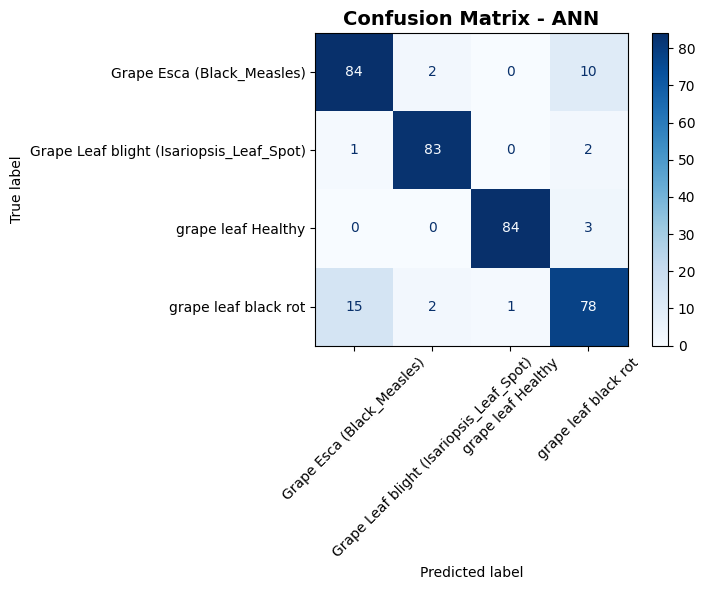

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

try:
    y_true_clean = le.inverse_transform(y_test)
except:
    y_true_clean = y_test
    
try:
    y_pred_clean = le.inverse_transform(y_test_pred)
except:
    y_pred_clean = y_test_pred

cm = confusion_matrix(y_true_clean, y_pred_clean, labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - ANN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Evaluasi Model dengan Stratified K-Fold Cross Validation


In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
import numpy as np

# Menggabungkan StandardScaler dan model ANN ke dalam satu pipeline
cv_pipeline_ann = make_pipeline(StandardScaler(), ann)

# Membagi dataset menjadi 5 bagian yang seimbang rasio kelasnya
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Memulai 5-Fold Cross Validation untuk model MLP/ANN...")

cv_scores = cross_val_score(cv_pipeline_ann, X, y_encoded, cv=skf, scoring='accuracy', n_jobs=-1)

for i, score in enumerate(cv_scores, 1):
    print(f"Fold ke-{i} : {score:.4f} ({score * 100:.2f}%)")

print("-" * 30)
print(f"Rata-rata Akurasi (Mean) : {np.mean(cv_scores):.4f} ({np.mean(cv_scores) * 100:.2f}%)")
print(f"Standar Deviasi (Std)    : {np.std(cv_scores):.4f}")

Memulai 5-Fold Cross Validation untuk model MLP/ANN...
Fold ke-1 : 0.8986 (89.86%)
Fold ke-2 : 0.8849 (88.49%)
Fold ke-3 : 0.8986 (89.86%)
Fold ke-4 : 0.9014 (90.14%)
Fold ke-5 : 0.8849 (88.49%)
------------------------------
Rata-rata Akurasi (Mean) : 0.8937 (89.37%)
Standar Deviasi (Std)    : 0.0072
